In [1]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator,array_to_img
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,SeparableConv2D,MaxPooling2D,Lambda
from tensorflow.keras.layers import Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.layers import Conv2DTranspose,Conv2D,add,concatenate
from tensorflow.keras.layers import LeakyReLU,Activation,Reshape
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau

In [2]:
attributes=pd.read_csv(r"D:\Gan_data\list_attr_celeba.csv")
bboxes=pd.read_csv(r"D:\Gan_data\list_bbox_celeba.csv")
partition=pd.read_csv(r"D:\Gan_data\list_eval_partition.csv")
landmarks=pd.read_csv(r"D:\Gan_data\list_landmarks_align_celeba.csv")
base_directory="D:\Gan_data\img_align_celeba\img_align_celeba"

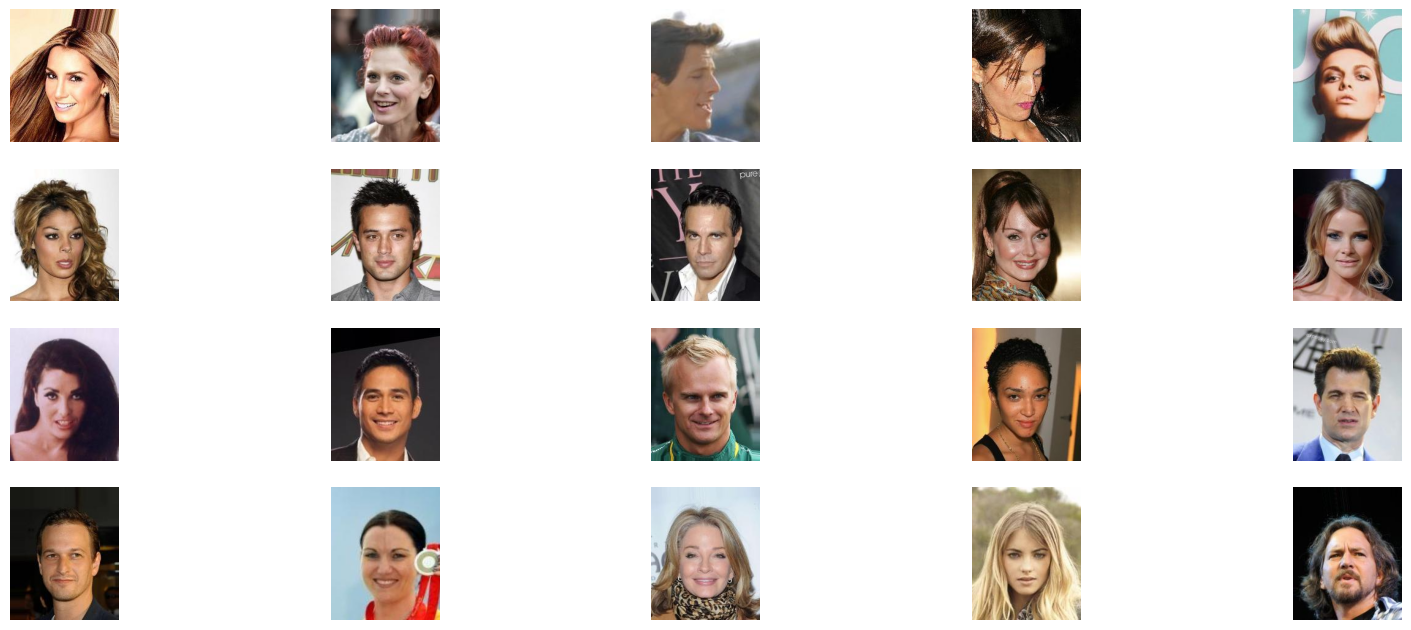

In [3]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

%matplotlib inline

image_paths = glob.glob(
    "D:/Gan_data/img_align_celeba/img_align_celeba/*.jpg"
)[:20]

images = [mpimg.imread(img) for img in image_paths]

plt.figure(figsize=(20,10))
columns = 5

for i, image in enumerate(images):
    plt.subplot(len(images)//columns + 1, columns, i + 1)
    plt.axis('off')
    plt.imshow(image)

plt.show()


Landmarks

In [4]:
landmarks.head()

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


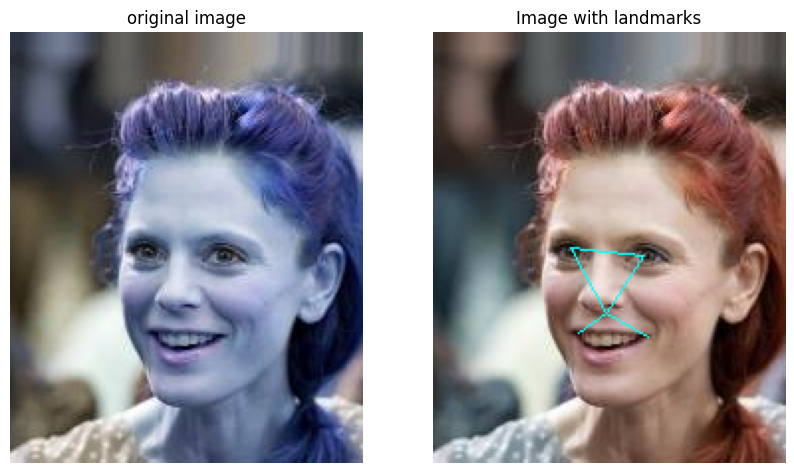

In [5]:
paths_to_images="D:\\Gan_data\\img_align_celeba\\img_align_celeba\\000002.jpg"

eye_x,eye_y,eye_w,eye_h=np.array(landmarks.iloc[:,1:5])[0]
nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y=np.array(landmarks.iloc[:,5:])[0]
left_eye=(eye_x,eye_y)
right_eye=(eye_w,eye_h)
nose=(nose_x+10,nose_y)
left_mouth=(leftmouth_x,leftmouth_y)
right_mouth=(rightmouth_x,rightmouth_y)

example_img=cv2.imread(paths_to_images)
original_img=example_img.copy()

example_img=cv2.cvtColor(example_img,cv2.COLOR_BGR2RGB)

example_img=cv2.line(example_img,left_eye,right_eye,(0,255,255),1)
example_img=cv2.line(example_img,left_eye,nose,(0,255,255),1)
example_img=cv2.line(example_img,right_eye,nose,(0,255,255),1)
example_img=cv2.line(example_img,nose,left_mouth,(0,255,255),1)
example_img=cv2.line(example_img,nose,right_mouth,(0,255,255),1)

plt.figure(figsize=(10,20))
plt.subplot(1,2,1)
plt.axis('off')
plt.title('original image')
plt.imshow(original_img)
plt.subplot(1,2,2)
plt.axis('off')
plt.title('Image with landmarks')
plt.imshow(example_img)

Bounding Box

In [6]:
bboxes.head()

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


     image_id  x_1  y_1  width  height
1  000002.jpg   72   94    221     306


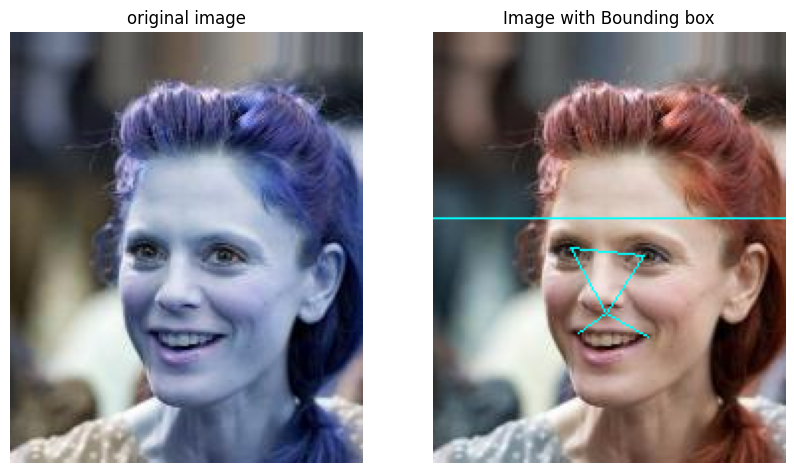

In [7]:
current_box=bboxes.query('image_id=="{}"'.format(paths_to_images.split('\\')[-1]))
print(current_box)
x,y,w,h=np.array(current_box.iloc[:,1:])[0]
example_img=cv2.rectangle(example_img,(x-w,y),(w,h),(0,255,255),1)

plt.figure(figsize=(10,20))
plt.subplot(1,2,1)
plt.axis('off')
plt.title('original image')
plt.imshow(original_img)
plt.subplot(1,2,2)
plt.axis('off')
plt.title('Image with Bounding box')
plt.imshow(example_img)

Partitions

In [8]:
partition.head()

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


In [9]:
partition['partition'].value_counts()

partition
0    162770
2     19962
1     19867
Name: count, dtype: int64

In [10]:
train_images=partition.query('partition==0')
valid_images=partition.query('partition==1')
test_images=partition.query('partition==2')

Attributes

In [11]:
attributes.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


Creating Discriminator

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

discriminator=keras.Sequential([
    keras.Input(shape=(64,64,3)),
    layers.Conv2D(64,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2D(128,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2D(128,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(1,activation='sigmoid'),
], name='discriminator')
discriminator.summary()

Model: "discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        3136      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       131200    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         262272    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 flatten (Flatten)           (None, 8192)            

Creating Generator

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

latent_dim=100
generator=keras.Sequential([
    keras.Input(shape=(latent_dim,)),
    layers.Dense(8*8*128),
    layers.Reshape((8,8,128)),
    layers.Conv2DTranspose(128,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2DTranspose(256,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2DTranspose(512,kernel_size=4,strides=2,padding='same'),
    layers.LeakyReLU(alpha=0.2),
    layers.Conv2D(3,kernel_size=5,padding='same',activation='sigmoid'),
],name='generator',)
generator.summary()

Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 8192)              827392    
                                                                 
 reshape (Reshape)           (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 16, 16, 128)      262272    
 nspose)                                                         
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 32, 32, 256)      524544    
 ranspose)                                                       
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 32, 32, 256)       0 

In [14]:
dataset=keras.preprocessing.image_dataset_from_directory("D:\\Gan_data",label_mode=None,image_size=(64,64),batch_size=32)
dataset=dataset.map(lambda x:x/255.0)

Found 202599 files belonging to 1 classes.


Train_step

In [15]:
class GAN(keras.Model):
    def __init__(self,discriminator,generator,latent_dim):
        super(GAN,self).__init__()
        self.discriminator=discriminator
        self.generator=generator
        self.latent_dim=latent_dim
    
    def compile(self,d_optimizer,g_optimizer,loss_fn):
        super(GAN,self).compile()
        self.d_optimizer=d_optimizer
        self.g_optimizer=g_optimizer
        self.loss_fn=loss_fn
        self.d_loss_metric=keras.metrics.Mean(name='d_loss')
        self.g_loss_metric=keras.metrics.Mean(name='g_loss')
    
    @property
    def metrics(self):
        return [self.d_loss_metric,self.g_loss_metric]
    
    def train_step(self, real_images):
        # sample random points in latent space
        batch_size=tf.shape(real_images)[0]
        random_latent_vectors=tf.random.normal(shape=(batch_size,self.latent_dim))

        #decode them to fake images
        generated_images=self.generator(random_latent_vectors)

        # combining original and fake images(in original paper they used sepeartely but here concatinated)
        combined_images=tf.concat([generated_images,real_images],axis=0)

        #labels to combined images
        labels=tf.concat([tf.ones(batch_size,1),tf.zeros(batch_size,1)],axis=0)

        #Add random noise to labels
        labels+=0.05*tf.random.uniform(tf.shape(labels))

        # Train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample random points in the latent space
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # Assemble labels that say "all real images"
        misleading_labels = tf.zeros((batch_size, 1))

         # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }



Create a Callback that saves generated images priodically

In [19]:
class GANMonitor(keras.callbacks.Callback):
    
    def __init__(self, num_img=3, latent_dim=100):
        super().__init__()
        self.num_img = num_img
        self.latent_dim = latent_dim

        self.save_dir = r"D:\coding\DL\GANS\generated_images"
        os.makedirs(self.save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):

        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors,training=False)
        generated_images = generated_images * 255.0
        plt.figure(figsize=(10, 4))
        for i in range(self.num_img):
            img = keras.preprocessing.image.array_to_img(generated_images[i])
            img_path = os.path.join(self.save_dir,f"generated_img_epoch_{epoch+1:03d}_{i}.png")
            img.save(img_path)
            plt.subplot(1, self.num_img, i + 1)
            plt.imshow(img)
            plt.axis("off")
        plt.show()

+Train Whole Model

6332/6332 [==============================] - ETA: 0s - d_loss: 0.6200 - g_loss: 1.1718

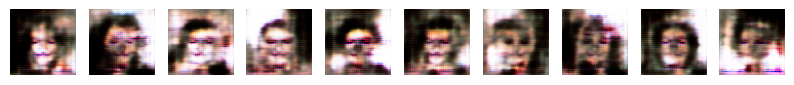

6332/6332 [==============================] - 6317s 997ms/step - d_loss: 0.6200 - g_loss: 1.1718


In [18]:
epochs = 1  # In practice, use ~100 epochs

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(
    dataset, epochs=epochs, callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)]
)